线性回归的投影视角
数据点: 50 个
A 的形状: (50, 2)

拟合结果: y = 1.978 * x + 1.097
真实值:   y = 2.000 * x + 1.000

投影（拟合值）前5个: [ 8.504 19.899 15.573 12.936  4.182]
误差（残差）前5个: [ 0.725  0.287 -0.049 -0.264 -1.54 ]
误差平方和: 41.154

误差与截距列正交？ -0.000000 (应为0)
误差与x列正交？ 0.000000 (应为0)


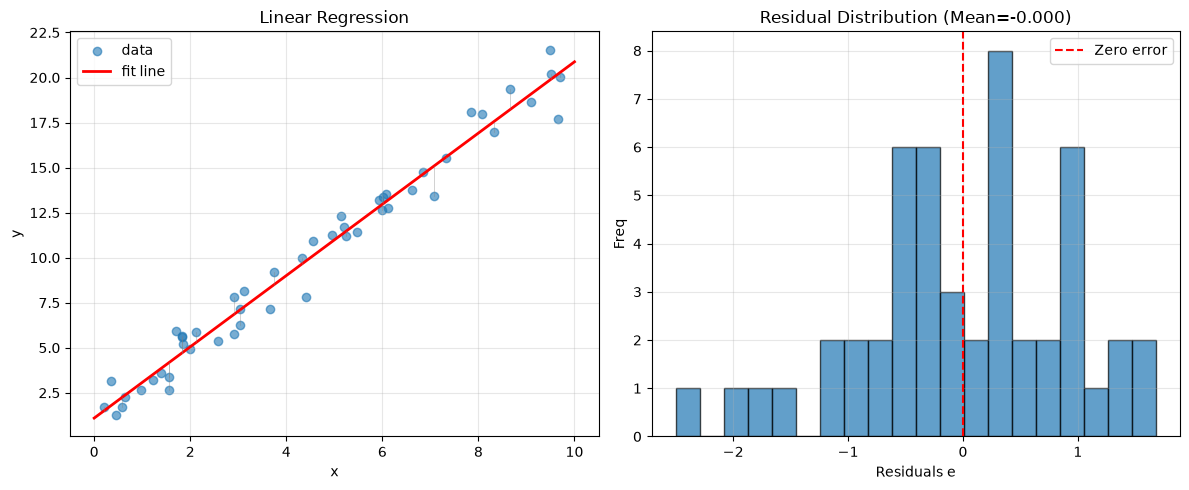


投影矩阵的性质
P 是对称的？ True
P 是幂等的？ True
投影矩阵的迹 = 2.000 (应该等于秩，即2)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 生成数据：y = 2*x + 1 + 噪声 ----
np.random.seed(42)
n = 50
x = np.random.uniform(0, 10, n)
true_intercept = 1.0
true_slope = 2.0
noise = np.random.normal(0, 1.0, n)
y = true_intercept + true_slope * x + noise

# ---- 构建设计矩阵 ----
# 第一列：截距（全是1），第二列：x
A = np.column_stack([np.ones(n), x])

print("=" * 60)
print("线性回归的投影视角")
print("=" * 60)
print(f"数据点: {n} 个")
print(f"A 的形状: {A.shape}")

# ---- 用正规方程求解 ----
# x_hat = (A^T A)^{-1} A^T b
x_hat = np.linalg.solve(A.T @ A, A.T @ y)
intercept, slope = x_hat
print(f"\n拟合结果: y = {slope:.3f} * x + {intercept:.3f}")
print(f"真实值:   y = {true_slope:.3f} * x + {true_intercept:.3f}")

# ---- 计算投影 p 和误差 e ----
p = A @ x_hat  # 投影：列空间中最接近 y 的点
e = y - p      # 误差：垂直于列空间

print(f"\n投影（拟合值）前5个: {p[:5].round(3)}")
print(f"误差（残差）前5个: {e[:5].round(3)}")
print(f"误差平方和: {np.sum(e**2):.3f}")

# ---- 验证误差与列空间正交 ----
col1 = A[:, 0]  # 全是1
col2 = A[:, 1]  # x
print(f"\n误差与截距列正交？ {np.dot(e, col1):.6f} (应为0)")
print(f"误差与x列正交？ {np.dot(e, col2):.6f} (应为0)")

# ---- 可视化 ----
plt.figure(figsize=(12, 5))

# 图1：数据与拟合直线
plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.6, label='data')
x_plot = np.linspace(0, 10, 100)
plt.plot(x_plot, intercept + slope * x_plot, 'r-', linewidth=2, label='fit line')
for i in range(min(n, 20)):  # 只画前20个点的误差线
    plt.plot([x[i], x[i]], [y[i], p[i]], 'gray', linewidth=0.5, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(alpha=0.3)

# 图2：残差分布
plt.subplot(1, 2, 2)
plt.hist(e, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Zero error')
plt.xlabel('Residuals e')
plt.ylabel('Freq')
plt.title(f'Residual Distribution (Mean={np.mean(e):.3f})')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 投影矩阵 ----
P = A @ np.linalg.inv(A.T @ A) @ A.T
print("\n" + "=" * 60)
print("投影矩阵的性质")
print("=" * 60)
print(f"P 是对称的？ {np.allclose(P, P.T)}")
print(f"P 是幂等的？ {np.allclose(P @ P, P)}")
print(f"投影矩阵的迹 = {np.trace(P):.3f} (应该等于秩，即2)")